<a href="https://colab.research.google.com/github/jccrews256/ST-554-HW-5/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST 554 Homework 5

*By: Cass Crews*

## Part I: Concepts



#### Question 1

*Prompt: We discussed the “Five V's of Big Data”. Give an example of a place where you've encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V's for
the example and whether/how they apply to your example.*

I am currently leading a team that is building a relational database of socioeconomic data, which is used to build custom data dashboards and decision-making tools for communities that can't afford products from for-profit data providers. This database generally connects to public and proprietary datasets through APIs, with API calls rununing at the end of each day to ensure the data are up to date.

The five V's of big data map to this project in the following ways:

* Volume: The data are stored in the cloud for ease of access from the web-based dashboards and tools. At roughly four gigabytes of data, it would not be impossible to analyze and visualize the data locally on a standard work laptop. However, the cloud-based storage and analysis of this dataset is more manageable even if the utilization of the cloud is largely for online broadcasting purposes.
* Variety: The data come from 28 different sources and cover several geographic levels. Thus, the data exhibit substantial variety, which results in thousands of lines of code being necessary to automate the process of cleaning and relating the data.
    * For anyone interested, most geographies we focus on are counties or collections of counties. Thus, tables are related by multiple heirarchically structured keys that connect individual counties to broader regions.
* Velocity: By batch-updating the raw data daily, the "velocity" of the database is controlled in one sense. However, in reality, velocity is determined by the release schedules of the sources. Some sources, such as the Census Bureau's American Community Survey, have fixed annual release schedule, while other sources have less predictable releases. The uncertainty makes maintenance a bit tricky, as an unpredictable source data update may also involve an unpredictable update to the structure of the corresponding raw data. We build fail-safes into the data cleaning scripts, but we can't foresee all structure changes!
* Veracity/Variability: This V comes in two major ways.
    * First, effectively every value we visualize, report, or analyze for communities is an estimate of some community characteristic extracted from surveys or government administrative records. My team and I view it as our job to quantify, or at least understand, this uncertainty for each potential data source to identify the least variable (and least biased) measure of a given socioeconomic characteristic; as an example, we prefer employment data built from administrative records rather than survey-based data.
    * Second, uncertainty around new and revised observations makes related machine learning challenging. As an example, we have built clustering models to identify structural peers for communities; these match communities in terms of "economic inputs" such as the industry mix of employment. However, even these "inputs" can be impacted by major economic downturns. This means that any assymetry in an economic downturn's impacts across the United States could have a massive impact on model-identified peers. I'm still evaluating options for handling this uncertainty and its impact on model stability.
* Value: This is the north star of the project. Our goal is to majorly reduce the barriers to data-backed decision making, so we are explicitly focused on extracting value/signals from socioeconomic data to generate better outcomes for communities' residents.

#### Question 2

*Prompt: Read about the database we'll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database.*

Below are examples of how each element of CRUD aplies to the Major League Baseball database:

* Create data: One notable omission is a table containing season-level data on front-office characteristics. We could create a new table within a database that includes front office staff count as well as staff count by department (e.g., the data science department)
* Read data: This is largely what we are doing in Part IV. We are identifying some combination of the tables we want, such as the batting statistics for each player (`Batting`) as well as the the more biographical information for each player, and using SQL queries to extract the data of interest from the database.
* Update data: Suppose we find errors in the player-level home run totals for the 1974 season. We could utilize an `UPDATE` clause to replace the incorrect tallies for the correct ones.
* Delete data: If we decide the `People` table has player and manager information that is of a sensative nature, such as mailing address, we could use a `DROP TABLE` clause to remove this table entirely and preserve the individuals' privacy.  



#### Question 3

*Prompt: What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the SELECT statement.)*

The purpose of the HAVING clause is to subset the groups created by a GROUP BY clause. That is, once the GROUP BY clause creates aggregate records summarizing groups of observations, the HAVING clause filters the aggregate records by some logical specified by the query writer in the clause.


## Part II: Simulation of a Sampling Distribution

#### Question 4

In this part, we will use simulation to study the sampling distribution of the sample slope in a simple linear regression (SLR) model. More specifically, we will assume the following model for the relationship between a response, $Y$, and a predictor, $x$,

$$Y_i = \beta_0 + \beta_1 x_i + E_i.$$

$Y_i$ and $x_i$ are the $i$th observations of the response and predictor, respectively, with $i=1,...,n$. We will assume $E_i \overset{iid}{\sim}N(0,1)$. Our simulation will explore the sampling distribution of $\hat{\beta}_1$, the ordinary least square estimate for $\beta_1$.

To study the slope estimate via simulation, we will need to repeatedly draw response and predictor values from the same distributions and fit an SLR model to the simulated data.

The code chunk provided in the instructions demonstrates the process of simulating a single dataset. The predictor values are "generated" by assuming we three observations of $x$ at each integer from 0 to 10; this implies $n$=33. The response values are generated by assuming $\beta_0$=7 and $\beta_1$=1.5. The code chunk is run below. It produces a plot of the single simulated dataset.


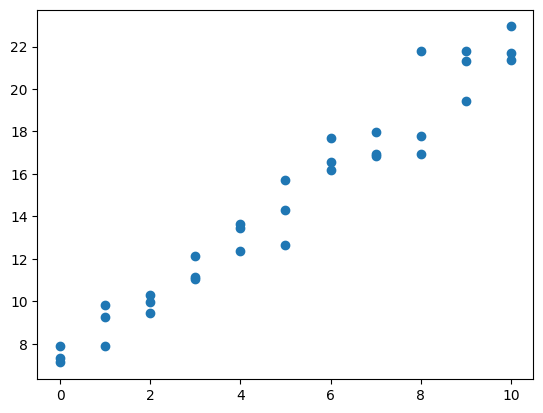

In [34]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()


Note that the relationship between our predictor and response is relatively strong because of the scale of the true slope value in comparison to the variability of $Y$ about its conditional mean ($\sigma^2=1$).

Now that we are able to simulate a dataset, we need to be able to extract the slope estimate relating $Y$ and $x$. To do so, we will use the `linear_model` submodule from `sklearn`.

In [35]:
# Read in linear_model submodule
from sklearn import linear_model

# Create a reg object
reg = linear_model.LinearRegression()

# Fit model between Y and x and print coefficients
reg.fit(x.reshape(-1,1), y)
print(reg.intercept_, reg.coef_)

7.259043801350283 [1.47450564]


Because of the strength of the simulated relationship between the response and predictor, we were able to fit the model relatively well; both coefficient estimates are fairly close to the true values.

We now want to repeat this process of simulating a dataset and fitting an SLR model 5,000 times to obtain a simulated sampling distribution for $\hat{\beta}_1$. To do so, we will construct a `for` loop that will repeat the above process. The 5,000 slope values will be capturing in a `numpy` array, `slopes`.

In [36]:
# Creating an array to capture slope estimates
slopes = np.zeros(5000)

for i in range(5000):
    # Get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33
    # Create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # Fitting model to simulated data
    reg.fit(x.reshape(-1,1), y)

    # Capturing estimated slope
    slopes[i] = reg.coef_[0]


Let's print the first and final few slopes to ensure the code worked as intended.


In [37]:
print("First five estimates:", slopes[:5])
print("Final five estimates:", slopes[-5:])

First five estimates: [1.45280552 1.53315358 1.47203179 1.44166898 1.48156797]
Final five estimates: [1.46147432 1.46119866 1.5023274  1.50048984 1.54545847]


It seems our `for` loop worked, so we are ready to explore the simulated sampling distribution. We will begin with a visual exploration: a histogram of the 5,000 slope estimates.

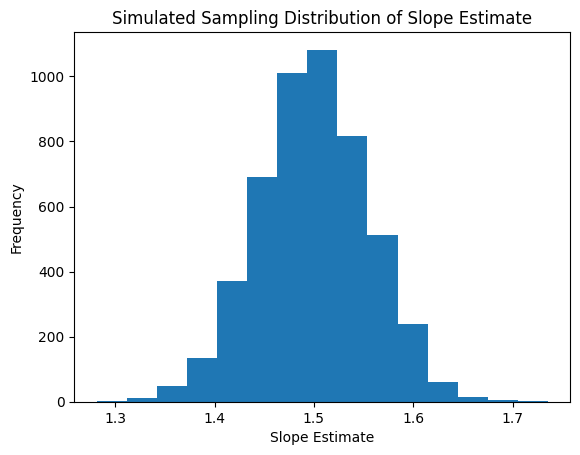

In [92]:
# Creating a basic histogram of slope coefficients with 15 bins
plt.hist(slopes, bins = 15)
plt.xlabel("Slope Estimate")
plt.ylabel("Frequency")
plt.title("Simulated Sampling Distribution of Slope Estimate")
plt.show() # Recently learned this gets rid of the metadata printed by Python

Statistical theory tells us the sampling distribution of the slope estimate is normally distributed when our errors are normally distributed, so it is not surprising to see a bell curve for our 5,000 estimates.

We can use this simulated sampling distribution to estimate the probability of obtaining slope estimates at least as extreme as a certain value. For example, we can estimate the probability of obtaining a slope estimate above 1.65 given that the true slope is 1.5. Let's try that now.

In [39]:
# Estimating probability of a slope above 1.65
prob = np.sum(slopes > 1.65)/slopes.shape[0]

print("Probability of obtaining a slope estimate above 1.65:", prob)

Probability of obtaining a slope estimate above 1.65: 0.0038


Given that the true slope is 1.5, the estimated probability of obtaining a slope estimate greater than 1.65 is 0.0038. Thus, an estimate this high is extreemely unlikely. Such information can be very useful when conducting hypothesis testing. For example, if our null hypothesis is that the true slope is 1.5 and our other model assumptions are reasonable, obtaining a sample slope above 1.65 would lead us to question whether our null hypothesis is valid. More directly, if our alternative hypothesis is that the true slope is actually higher than 1.5, we would reject the null hypothesis for most standard significance levels (e.g., a 0.01 or 0.05 significance level) due to the estimated probability being so low.

## Part III: Big Data Examples and Rare Events

For Part III, we will review three different paper highlighting opportunities and challenges in big data modeling.

#### Question 5

For this question, we are reviewing the paper [Biases in machine learning models and big data analytics: The international criminal and humanitarian law implications](https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913). In particular, we are identifying an example of bias negatively impacting a machine learning model and discussing ways to overcome this bias.

The example we will focus on in this notebook highlights an example of implicit bias:

> "In 2018, for example, Amazon found that algorithms used to screen résumés to identify candidates were trained on data containing implicit biases against female applicants, resulting in the algorithm penalizing résumés that included the word 'women,' as in 'women's chess club captain.'"

This is an example of implicit biases because hiring managers' implicit biases against women candidates were baked into the models trained on their hiring decisions. The key to overcoming this issue is often to identify it before training the model and stratify the training set accordingly. That is, if the data scientist knows there are implicit biases against women candidates, they could construct a training set with equal numbers of women who were hired, women who were not hired, men who were hired, and men who were not hired. This "equalization" of probabilities of being in each group for the training set will naturally counter the implicit biases in managers that result in more men and fewer women being hired. Of course, this solution may not fully resolve the issue on it's own, but it is a good first step.

#### Question 6

For this question, we will discuss the use of big data in creating a three-dimensional characterization of Earth's oceans, as described in [Big data in Earth Science: Emerging Practice and Promise](https://www.science.org/doi/10.1126/science.adh9607). The paper notes that combinations of underwater vehicles and buoy-based measurement tools have been used to create a 3-D model of the oceans. In effect, overlapping arrays of measurement devices have been deployed across the world, mapping and measuring the oceans in a variety ways across time. How big are these data? In some ways, a single temporal instance is the size of the ocean itself.

When I consider complexities related to these data, I fixate on one concern: that each measurement tool likely has its own biases: A device attached to a buoy may consistently overestimate depth in the deepest parts of the ocean (where we have little ground truth data) while also suffering from temperature reading drift. The computer vision model used to map the ocean floor via videos recorded by an underwater vehicle could generate surfaces that are much too smooth. I suspect these biases proliferate as the models processing data from a new type of sensor may be trained on biased data generated before it. Overall, the biases of individual measurement tools create a mosaic of oceanic measurements with their own location- and tool-specific biases.

One final thought: for any sections of the ocean so deep that they can only be effectively mapped by unmanned underwater vehicles, observations likely suffer from major time gaps between consecutive measurements, meaning that a key characteristic of the ocean floor may change in these areas long before a new observation informs us of this change. I wonder how effectively models using buoy-based data collection can predict when such a change occurs in the deep depths of our oceans!

#### Question 7

For this question, we will discuss the topic of rare events. This [article](https://allendowney.substack.com/p/superbolts) highlights one important rare event: the superbolt, or extraordinarily powerful lightning strike.

In general, extreme weather events offer salient examples of the importance of accurately modeling rare events: if we underestimate the likelihood of these extreme events, we may develop roads and buildings that cannot withstand an event that is much more common than we may think. Of course, the dynamic component of these distributions makes things even more complicated. For example, homes and commercial buildings across the Deep South were designed under the assumption that major tornadoes are very unlikely. However, weather patterns have substantially shifted over the past few decades, creating a region that is now highly prone to major tornadoes. I saw the impact of the underestimation of the major tornado rate first hand when, on April 27, 2011, [62 tornadoes touched down](https://www.weather.gov/bmx/event_04272011) in my home state of Alabama; three of these tornadoes were among the strongest tornadoes ever recorded.

## Part IV: Querying a Database

For Part IV, we will explore a database containing characteristics of Major League Baseball players and teams. We will use SQL queries to do so.

#### Question 8

Before querying the database, we need to form a connection and determine the tables it contains. We will use the `sqlite3` module to assist in the connection process.

*Note to reader: The file is too large to be stored in a GitHub repository, so it will need to be brought into your own Colab environment if you are attempting to recreate my results.*

In [40]:
# Bringing in the sqlite3 module
import sqlite3
# Make connection to database file; I stored the file "locally" in the colab
# environment
con = sqlite3.connect("lahman_1871-2022.sqlite")

# Constructing SQL query to access tables in schema
get_schema = """
    SELECT *
    FROM sqlite_schema
    WHERE type = "table";
    """

# Obtaining tables from schema
baseball_tables = pd.read_sql(get_schema, con)

# Printing tables
baseball_tables

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


In skimming the table, we see this is a very informative database, containing everything from batting, field, and pitching statistics to the winners of major awards and player salaries.

#### Problem 9

Now that we generally understand what's in the database, let's explore a few tables. We will start by using the `Teams` table to access the list of teams that participated in the 2015 season. We'll grab all columns corresponding to those teams' 2015 season, and we'll also order the teams by number of wins across the the 162-game regular season.

In [41]:
# Constructing SQL query to access teams for the 2015 season
get_teams = """
    SELECT *
    FROM Teams
    WHERE yearID = 2015
    ORDER BY W DESC;
    """

# Returning the teams
pd.read_sql(get_teams, con)

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,NL,SLN,STL,C,1,162,81,100,62,...,159,0.984,St. Louis Cardinals,Busch Stadium III,3520889,102,101,STL,SLN,SLN
1,2015,NL,PIT,PIT,C,2,162,81,98,64,...,177,0.981,Pittsburgh Pirates,PNC Park,2498596,99,97,PIT,PIT,PIT
2,2015,NL,CHN,CHC,C,3,162,81,97,65,...,120,0.982,Chicago Cubs,Wrigley Field,2919122,100,100,CHC,CHN,CHN
3,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
4,2015,AL,TOR,TOR,E,1,162,81,93,69,...,145,0.985,Toronto Blue Jays,Rogers Centre,2794891,99,98,TOR,TOR,TOR
5,2015,NL,LAN,LAD,W,1,162,81,92,70,...,133,0.988,Los Angeles Dodgers,Dodger Stadium,3764815,101,98,LAD,LAN,LAN
6,2015,NL,NYN,NYM,E,1,162,81,90,72,...,131,0.986,New York Mets,Citi Field,2569753,94,92,NYM,NYN,NYN
7,2015,AL,TEX,TEX,W,1,162,81,88,74,...,169,0.981,Texas Rangers,Globe Life Park in Arlington,2491875,102,105,TEX,TEX,TEX
8,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA
9,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU


The St. Louis Cardinals were the only team to win 100 games in the 2015 season. Fun fact: I was living in St. Louis in 2015 and attended a few of those wins!

#### Question 10

Let's dig a bit deeper. In particular, let's obtain all the individuals in the Hall of Fame, the year each was voted in, and the category for each. To identify only inductees and the year they were voted in, we will subset to only cases where `inducted = "Y"`. Confusingly, `playerID` is actually a unique identifier for all individuals in the database, but we can overcome this confusion by renaming the column `ID`.

In [51]:
# Constructing SQL query to obtain HoFers and the year they were voted in
get_hofs = """
    SELECT playerID as ID, yearid as year_inducted, category
    FROM HallOfFame
    WHERE inducted = "Y";
    """

# Returning the HoFers
pd.read_sql(get_hofs, con)

,ID,year_inducted,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


We now have a list of 340 Hall of Fame members, their induction year, and their category. Of course, it would be helpful to know the members' names rather than simply their ID's. Let's take the additional step of pulling in player names from the `People` table.

In [50]:
# Constructing SQL query to obtain HoFers and the year they were voted in
# Adding first and last names from People table
get_hofs = """
    SELECT HallOfFame.playerID as ID, yearid as year_inducted, nameLast, nameGiven, category
    FROM HallOfFame
    LEFT JOIN People ON HallOfFame.playerID = People.playerID
    WHERE inducted = "Y";
    """

# Returning the HoFers
pd.read_sql(get_hofs, con)

,ID,year_inducted,nameLast,nameGiven,category
0,aaronha01,1982,Aaron,Henry Louis,Player
1,alexape01,1938,Alexander,Grover Cleveland,Player
2,alomaro01,2011,Alomar,Roberto,Player
3,alstowa01,1983,Alston,Walter Emmons,Manager
4,andersp01,2000,Anderson,George Lee,Manager
...,...,...,...,...,...
335,yastrca01,1989,Yastrzemski,Carl Michael,Player
336,yawketo99,1980,Yawkey,Thomas Austin,Pioneer/Executive
337,youngcy01,1937,Young,Denton True,Player
338,youngro01,1972,Youngs,Royce Middlebrook,Player


I've heard Hank Louis Aaron was a pretty great baseball player, so it makes sense he's a member....

#### Question 11

Ever wanted to obtain a list of all the managers the Pittsburg Pirates have ever had? I know I have, so let's create it using the `Managers` table.

In [49]:
# Constructing a SQL query to obtain Pirates managers
get_managers = """
    SELECT DISTINCT playerID as ID
    FROM Managers
    WHERE teamID = "PIT";
    """

# Returning the managers
pd.read_sql(get_managers, con)

,ID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


We now have the IDs for all individuals who have managed the Pirates. Again, it would be helpful to have their names in addition to their ID's, so let's grab those from the `People` table.

In [52]:
# Constructing a SQL query to obtain Pirates managers
get_managers = """
    SELECT DISTINCT Managers.playerID as ID, nameLast, nameGiven
    FROM Managers
    LEFT JOIN People ON Managers.playerID = People.playerID
    WHERE teamID = "PIT";
    """

# Returning the managers
pd.read_sql(get_managers, con)

,ID,nameLast,nameGiven
0,bezdehu99,Bezdek,Hugo Francis
1,bragabo01,Bragan,Robert Randall
2,buckeal99,Buckenberger,Albert C.
3,burnsto01,Burns,Thomas Everett
4,burwebi01,Burwell,William Edwin
5,bushdo01,Bush,Owen Joseph
6,callani01,Callahan,James Joseph
7,clarkfr01,Clarke,Fred Clifford
8,davissp01,Davis,Virgil Lawrence
9,donovpa01,Donovan,Patrick Joseph


Forty-one managers seems like a lot for a single team. I'd be curious to know which teams have the lowest and highest average manager tenures.

#### Question 12

Which managers have been inducted into the Hall of Fame, regardless of whether it was as a player, manager, or pioneer of the game? We can figure this out by performing an inner join on the `Managers` and `Hall of Fame` tables. Note that we will need to utilize a `SELECT DISTINCT` clause to handle the fact that the rows of the `Managers` table correspond to manager-season combinations. We will also need to utilize a `WHERE` clause to handle the fact that the `HallOfFame` table contains separate rows for each year an individual was considered for Hall of Fame induction.

To overcome the confusing fact that all individuals in this dataset have a `playerID` regardless of whether or not they played professional baseball, we will again rename this column `ID`.

In [63]:
# Constructing a table of managers in the Hall of Fame
get_managers_in_hof = """
    SELECT DISTINCT Managers.playerID as ID
    FROM Managers
    INNER JOIN HallOfFame on Managers.playerID = HallOfFame.playerID
    WHERE inducted = "Y"
    """

# Creating data frame with managers in the Hall of Fame
managers_in_hof = pd.read_sql(get_managers_in_hof, con)

# Printing the managers
managers_in_hof

,ID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


We now have the list of unique ID's corresponding to the managers in the Hall of Fame.

Because `managers_in_hof` is a data frame, Python conveniently prints its dimensions when we print the table. However, it may be beneficial in the future to programmatically extract the number of unique managers in the Hall of Fame. To do this, we can utilize the `.shape` attribute.

In [66]:
# Printing number of managers in the HoF
print("There are", managers_in_hof.shape[0],
      "previous or current managers in the Hall of Fame.")

There are 97 previous or current managers in the Hall of Fame.


There are fewer than 100 prior or current managers in the Hall of Fame. That's a rather select group to be a part of.

For such an elite group, they deserve to have their names printed alongside their ID's. Let's add those.

In [68]:
# Updating the managers in the HoF query to include manager names
# Constructing a table of managers in the Hall of Fame
get_managers_in_hof = """
    SELECT DISTINCT Managers.playerID as ID, nameLast, nameGiven
    FROM Managers
    INNER JOIN HallOfFame on Managers.playerID = HallOfFame.playerID
    LEFT JOIN People on Managers.playerID = People.playerID
    WHERE inducted = "Y"
    """

# Creating data frame with managers in the Hall of Fame
managers_in_hof = pd.read_sql(get_managers_in_hof, con)

# Printing the managers
managers_in_hof

,ID,nameLast,nameGiven
0,alstowa01,Alston,Walter Emmons
1,andersp01,Anderson,George Lee
2,ansonca01,Anson,Adrian Constantine
3,applilu01,Appling,Lucius Benjamin
4,baineha01,Baines,Harold Douglas
...,...,...,...
92,willidi02,Williams,Richard Hirschfeld
93,willite01,Williams,Theodore Samuel
94,wrighge01,Wright,George
95,wrighha01,Wright,William Henry


Congratulations, Denton True Young. You win the award for most unique middle name among the managers in the Hall of Fame.

#### Question 13

Let's learn a bit more about these managers who are in the Hall of Fame. In particular, let's calculate their win percentages as managers. To start, we need to create a new data frame that contains data on each season the managers managed a team; we will aggregate wins and losses from the season-level data. This simply means we will not subset to only unique ID's for the managers, but rather retain all observations corresponding to a manager in the Hall of Fame.

Note: We will also pull in manager names from the `People` table so we know exactly who the winning percentage correspond to.

In [70]:
# Constructing a SQL query to obtain season-level data for each manager in the
# HoF
get_manager_seasons = """
    SELECT Managers.playerID as ID, nameLast, nameGiven, G, W, L
    FROM Managers
    INNER JOIN HallOfFame on Managers.playerID = HallOfFame.playerID
    LEFT JOIN People on Managers.playerID = People.playerID
    WHERE inducted = "Y";
    """
# Reading season-level data into a data frame
hof_manager_seasons = pd.read_sql(get_manager_seasons, con)

# Printing the data frame
hof_manager_seasons

,ID,nameLast,nameGiven,G,W,L
0,alstowa01,Alston,Walter Emmons,154,92,62
1,alstowa01,Alston,Walter Emmons,154,98,55
2,alstowa01,Alston,Walter Emmons,154,93,61
3,alstowa01,Alston,Walter Emmons,154,84,70
4,alstowa01,Alston,Walter Emmons,154,71,83
...,...,...,...,...,...,...
991,wrighha01,Wright,William Henry,46,22,23
992,wrighha01,Wright,William Henry,138,68,69
993,wrighha01,Wright,William Henry,155,87,66
994,wrighha01,Wright,William Henry,133,72,57


We now have a data frame with 996 season-manager pairs. Let's use our `pandas` skills to collapse the data frame to career-level games, wins, and losses.

In [74]:
# Collapsing to career games, wins, and losses
hof_manager_careers = hof_manager_seasons.groupby(["ID", "nameLast", "nameGiven"])[["G","W","L"]].sum()

# Printing collapse data frame
hof_manager_careers

,,,G,W,L
ID,nameLast,nameGiven,,,
alstowa01,Alston,Walter Emmons,3658,2040,1613
andersp01,Anderson,George Lee,4030,2194,1834
ansonca01,Anson,Adrian Constantine,2288,1296,947
applilu01,Appling,Lucius Benjamin,40,10,30
baineha01,Baines,Harold Douglas,4,1,3
...,...,...,...,...,...
willidi02,Williams,Richard Hirschfeld,3023,1571,1451
willite01,Williams,Theodore Samuel,637,273,364
wrighge01,Wright,George,85,59,25


We now have a row for each manager in the Hall of Fame reporting their total games, wins, and losses as a manager. We're now ready to calculate career win percentages.

In [76]:
# Calculating win percentages
hof_manager_careers["win_percent"] = 100*hof_manager_careers.W/(hof_manager_careers.W+hof_manager_careers.L)

# Printing updated dataset
hof_manager_careers

,,,G,W,L,win_percent
ID,nameLast,nameGiven,,,,
alstowa01,Alston,Walter Emmons,3658,2040,1613,55.844511
andersp01,Anderson,George Lee,4030,2194,1834,54.468719
ansonca01,Anson,Adrian Constantine,2288,1296,947,57.779759
applilu01,Appling,Lucius Benjamin,40,10,30,25.000000
baineha01,Baines,Harold Douglas,4,1,3,25.000000
...,...,...,...,...,...,...
willidi02,Williams,Richard Hirschfeld,3023,1571,1451,51.985440
willite01,Williams,Theodore Samuel,637,273,364,42.857143
wrighge01,Wright,George,85,59,25,70.238095


We now have the win percentages for each manager, and some of the values are eye-opening: the fact that Lucius Appling only managed 40 games and only won 10 of those games is a stark reminder that not all of these managers made the Hall of Fame because of their managerial success.

As a final step, let's sort the data frame by win percentage to find out which manager in the Hall of Fame has the highest percentage.

In [80]:
# Sorting managers from highest to lowest win percentage
hof_manager_careers.sort_values("win_percent", ascending = False)

,,,G,W,L,win_percent
ID,nameLast,nameGiven,,,,
simmote01,Simmons,Ted Lyle,1,1,0,100.000000
wrighge01,Wright,George,85,59,25,70.238095
spaldal01,Spalding,Albert Goodwill,126,78,47,62.400000
mccarjo99,McCarthy,Joseph Vincent,3487,2125,1333,61.451706
comisch01,Comiskey,Charles Albert,1410,840,541,60.825489
...,...,...,...,...,...,...
bottoji01,Bottomley,James Leroy,78,21,56,27.272727
applilu01,Appling,Lucius Benjamin,40,10,30,25.000000
baineha01,Baines,Harold Douglas,4,1,3,25.000000


This is very underwhelming.... The highest win percentage belongs to Ted Simmons, who only managed one game. In my humble opinion, we should declare the true winner to be Joseph McCarthy, who posted a win percentage above 60\% over nearly 3,500 games. That's quite the feat.

For fun, let's combine the entire process of calculating win percentages and sorting by those percentages in a single SQL query.

In [88]:
# Constructing a SQL query to obtain career-level data for each manager in the
# HoF
get_manager_careers = """
    SELECT Managers.playerID as ID, nameLast, nameGiven, sum(G) as G,
        sum(W) as W, sum(L) as L,
        100.0*sum(W)/(sum(W) + sum(L)) as win_percent
    FROM Managers
    INNER JOIN HallOfFame on Managers.playerID = HallOfFame.playerID
    LEFT JOIN People on Managers.playerID = People.playerID
    WHERE inducted = "Y"
    GROUP BY Managers.playerID, nameLast, nameGiven
    ORDER BY win_percent DESC;
    """
# Reading career-level data into a data frame
hof_manager_careers2 = pd.read_sql(get_manager_careers, con)

# Printing the data frame
hof_manager_careers2

,ID,nameLast,nameGiven,G,W,L,win_percent
0,simmote01,Simmons,Ted Lyle,1,1,0,100.000000
1,wrighge01,Wright,George,85,59,25,70.238095
2,spaldal01,Spalding,Albert Goodwill,126,78,47,62.400000
3,mccarjo99,McCarthy,Joseph Vincent,3487,2125,1333,61.451706
4,comisch01,Comiskey,Charles Albert,1410,840,541,60.825489
...,...,...,...,...,...,...,...
92,bottoji01,Bottomley,James Leroy,78,21,56,27.272727
93,applilu01,Appling,Lucius Benjamin,40,10,30,25.000000
94,baineha01,Baines,Harold Douglas,4,1,3,25.000000
95,wagneho01,Wagner,John Peter,5,1,4,20.000000


In some ways, that was more convenient than combining a SQL query with `pandas` operations!